In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

def _detect_repo_root() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    return here


REPO_ROOT = _detect_repo_root()
MPLCONFIGDIR = REPO_ROOT / ".cache" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from core.block_irrep_mapper import BlockIrrepMapper
from data.block_matrix import BlockMatrix
from data.kspace_snapshot import KSpaceSnapshot, block_matrix_to_shiftspace_dense
from data.openmx_info_parser import parse_info_out
from data.snapshot import Snapshot
from net.common import Config


def fractional_kmesh_points(
    kmesh: tuple[int, int, int], *, device: torch.device, dtype: torch.dtype
) -> torch.Tensor:
    grids = [torch.arange(n, device=device, dtype=dtype) / float(n) for n in kmesh]
    points = torch.stack(torch.meshgrid(*grids, indexing="ij"), dim=-1)
    return points.reshape(-1, 3)


def show_figure(fig: plt.Figure) -> None:
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_box(ax, box: torch.Tensor, *, color: str = "black", alpha: float = 0.8):
    origin = torch.zeros(3, dtype=box.dtype)
    v1, v2, v3 = box[0], box[1], box[2]
    corners = {
        "000": origin,
        "100": v1,
        "010": v2,
        "001": v3,
        "110": v1 + v2,
        "101": v1 + v3,
        "011": v2 + v3,
        "111": v1 + v2 + v3,
    }
    edges = [
        ("000", "100"),
        ("000", "010"),
        ("000", "001"),
        ("100", "110"),
        ("100", "101"),
        ("010", "110"),
        ("010", "011"),
        ("001", "101"),
        ("001", "011"),
        ("110", "111"),
        ("101", "111"),
        ("011", "111"),
    ]
    for a, b in edges:
        p0 = corners[a]
        p1 = corners[b]
        ax.plot(
            [float(p0[0]), float(p1[0])],
            [float(p0[1]), float(p1[1])],
            [float(p0[2]), float(p1[2])],
            color=color,
            alpha=alpha,
            linewidth=1.8,
        )


def wrap_text_vec(vec: torch.Tensor, digits: int = 4) -> str:
    values = ", ".join(f"{float(v):.{digits}f}" for v in vec.tolist())
    return f"[{values}]"

In [2]:
si_dir = REPO_ROOT / "data" / "small" / "Si"
matrix_path = si_dir / "HS.out"
info_path = si_dir / "Si.out"
cif_path = si_dir / "Si.cif"
output_dir = REPO_ROOT / "eval_outputs" / "demo_06_silicon_snapshot_density_blockmatrix"
output_dir.mkdir(parents=True, exist_ok=True)

cfg = Config(
    cutoff_radius=8.0,
    verbosity=0,
    safety_checks=True,
)

print("Paths")
print("matrix:", matrix_path)
print("info  :", info_path)
print("cif   :", cif_path)

Paths
matrix: /home/bartek/casus/mandala/data/small/Si/HS.out
info  : /home/bartek/casus/mandala/data/small/Si/Si.out
cif   : /home/bartek/casus/mandala/data/small/Si/Si.cif


In [3]:
info = parse_info_out(info_path, dtype=cfg.dtype)

print("Parsed OpenMX info")
print("elements:", info.elements)
print("orbital set:", info.orbital_set)
print("positions shape:", tuple(info.positions.shape))
print("box shape:", tuple(info.box.shape))

Parsed OpenMX info
elements: ['Si', 'Si', 'Si', 'Si', 'Si', 'Si', 'Si', 'Si']
orbital set: {'Si': '2s2p1d'}
positions shape: (8, 3)
box shape: (3, 3)


In [4]:
snapshot = Snapshot.from_openmx(
    matrix_path=matrix_path,
    info_path=info_path,
    convention="e3nn",
    cutoff_radius=cfg.cutoff_radius,
    cfg=cfg,
)

print("Snapshot summary")
print(snapshot)
print("basis:", snapshot.density.basis)
print("cutoff radius:", snapshot.cutoff_radius)
print("energy (Tr[D H]):", float(snapshot.get_energy().item()))
print("electrons (Tr[D S]):", float(snapshot.get_number_of_electrons().item()))
print("atoms:", "".join(snapshot.density.atoms))
print("matrix keys:", sorted(snapshot.density.keys()))
print("translation shifts:", int(snapshot.get_translation_shifts().shape[0]))
print("max edge distance:", float(snapshot.max_distance().item()))

Snapshot summary
Snapshot(
  atoms   = SiSiSiSiSiSiSiSi
  keys    = ['Si-Si']
  basis   = e3nn
)
basis: e3nn
cutoff radius: 8.0
energy (Tr[D H]): -9.981070518493652
electrons (Tr[D S]): 31.999425888061523
atoms: SiSiSiSiSiSiSiSi
matrix keys: ['Si-Si']
translation shifts: 45
max edge distance: 7.698554039001465


/home/bartek/casus/mandala/mandala-venv/lib/python3.10/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(1, setting=1). This may result in wrong setting!
  warnings.warn(


In [5]:
density = snapshot.density
key = sorted(density.keys())[0]
blocks = density[key]
edges = density.edges(key)
edge_displacements = snapshot._edge_displacements(density)[key]
edge_distances = torch.linalg.norm(edge_displacements, dim=1)

print("Density BlockMatrix")
print("selected key:", key)
print("number of blocks:", blocks.shape[0])
print("block shape:", tuple(blocks.shape[1:]))
print("edge tensor shape:", tuple(edges.shape))
print("first five edges:")
print(edges[:, :5].t())

diag_density = density.diag()
offdiag_density = density.offdiag()

print("diag keys:", sorted(diag_density.keys()))
print("offdiag keys:", sorted(offdiag_density.keys()))
print("diag block count for", key + ":", int(diag_density[key].shape[0]))
print("offdiag block count for", key + ":", int(offdiag_density[key].shape[0]))

Density BlockMatrix
selected key: Si-Si
number of blocks: 792
block shape: (13, 13)
edge tensor shape: (5, 792)
first five edges:
tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 2, 2],
        [0, 0, 0, 3, 3],
        [0, 0, 0, 4, 4]])
diag keys: ['Si-Si']
offdiag keys: ['Si-Si']
diag block count for Si-Si: 8
offdiag block count for Si-Si: 784


Translation shifts
showing a truncated, shortest-first list
shift=(0, 0, 0)  cart=[0.0000, 0.0000, 0.0000]  |R|=0.0000  count=64
shift=(-1, 0, 0)  cart=[0.0000, 0.0000, -5.4437]  |R|=5.4437  count=47
shift=(0, -1, 0)  cart=[-5.4437, 0.0000, 0.0000]  |R|=5.4437  count=47
shift=(0, 0, -1)  cart=[0.0000, -5.4437, 0.0000]  |R|=5.4437  count=47
shift=(0, 0, 1)  cart=[0.0000, 5.4437, 0.0000]  |R|=5.4437  count=47
shift=(0, 1, 0)  cart=[5.4437, 0.0000, 0.0000]  |R|=5.4437  count=47
shift=(1, 0, 0)  cart=[0.0000, 0.0000, 5.4437]  |R|=5.4437  count=47
shift=(-1, -1, 0)  cart=[-5.4437, 0.0000, -5.4437]  |R|=7.6986  count=30
shift=(-1, 0, -1)  cart=[0.0000, -5.4437, -5.4437]  |R|=7.6986  count=30
shift=(-1, 0, 1)  cart=[0.0000, 5.4437, -5.4437]  |R|=7.6986  count=26
shift=(-1, 1, 0)  cart=[5.4437, 0.0000, -5.4437]  |R|=7.6986  count=26
shift=(0, -1, -1)  cart=[-5.4437, -5.4437, 0.0000]  |R|=7.6986  count=30


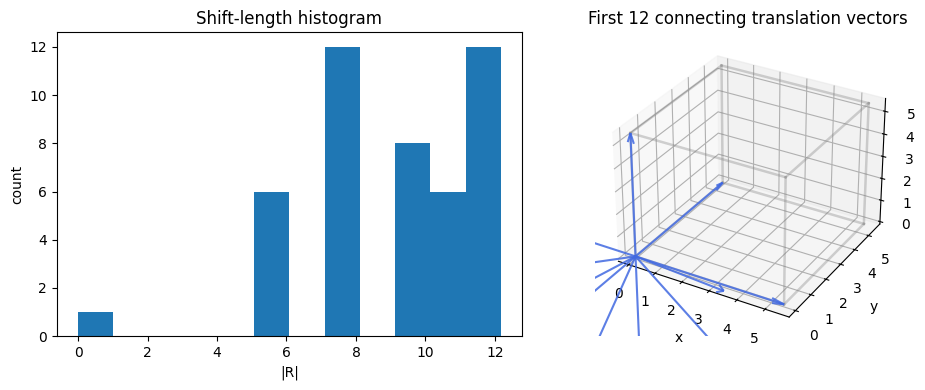

In [6]:
shifts = snapshot.get_translation_shifts()
shift_cart = shifts.to(dtype=snapshot.box.dtype) @ snapshot.box
shift_lengths = torch.linalg.norm(shift_cart, dim=1)
shift_counts: dict[tuple[int, int, int], int] = {
    tuple(int(v) for v in shift.tolist()): 0 for shift in shifts
}
for edges_key in density.pair_edges.values():
    for sx, sy, sz in edges_key[:3].t().tolist():
        key_shift = (int(sx), int(sy), int(sz))
        shift_counts[key_shift] = shift_counts.get(key_shift, 0) + 1

ranked_shifts = sorted(
    [
        (
            float(
                torch.linalg.norm(
                    torch.tensor(s, dtype=snapshot.box.dtype) @ snapshot.box
                ).item()
            ),
            s,
            shift_counts.get(s, 0),
        )
        for s in shift_counts
    ],
    key=lambda item: (item[0], item[1]),
)

print("Translation shifts")
print("showing a truncated, shortest-first list")
for length, shift, count in ranked_shifts[:12]:
    vec = torch.tensor(shift, dtype=snapshot.box.dtype) @ snapshot.box
    print(
        f"shift={shift}  cart={wrap_text_vec(vec)}  "
        f"|R|={length:.4f}  count={count}"
    )

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.hist(shift_lengths.cpu().numpy(), bins=min(12, int(shift_lengths.numel())))
ax1.set_title("Shift-length histogram")
ax1.set_xlabel("|R|")
ax1.set_ylabel("count")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for _, shift, _ in ranked_shifts[:12]:
    vec = torch.tensor(shift, dtype=snapshot.box.dtype) @ snapshot.box
    ax2.quiver(
        0.0,
        0.0,
        0.0,
        float(vec[0]),
        float(vec[1]),
        float(vec[2]),
        color="royalblue",
        alpha=0.85,
        arrow_length_ratio=0.08,
    )
ax2.set_title("First 12 connecting translation vectors")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
plot_box(ax2, snapshot.box, color="gray", alpha=0.35)
show_figure(fig)

Shortest connecting vectors for Si-Si
idx  src dst  shift            displacement                 |d|
  9    3   2   (-1, 0, -1)   [1.36092, -1.36092, -1.36092]  2.35719
 10    3   4   (0, -1, -1)   [-1.36092, -1.36092, 1.36092]  2.35719
 11    4   3     (0, 1, 1)    [1.36092, 1.36092, -1.36092]  2.35719
 12    2   3     (1, 0, 1)    [-1.36092, 1.36092, 1.36092]  2.35719
 13    0   3     (1, 1, 0)    [1.36092, -1.36092, 1.36092]  2.35719
  8    3   0   (-1, -1, 0)   [-1.36092, 1.36092, -1.36092]  2.35719
 27    7   6     (0, 0, 0)   [1.36092, -1.36092, -1.36092]  2.35719
 33    2   1     (1, 0, 0)    [1.36092, -1.36093, 1.36092]  2.35719
 32    0   1     (1, 0, 0)    [-1.36093, 1.36092, 1.36092]  2.35719
 31    4   7     (0, 1, 0)    [1.36092, -1.36093, 1.36092]  2.35719
 30    0   7     (0, 1, 0)    [1.36092, 1.36092, -1.36093]  2.35719
 29    4   5     (0, 0, 1)    [-1.36093, 1.36092, 1.36092]  2.35719


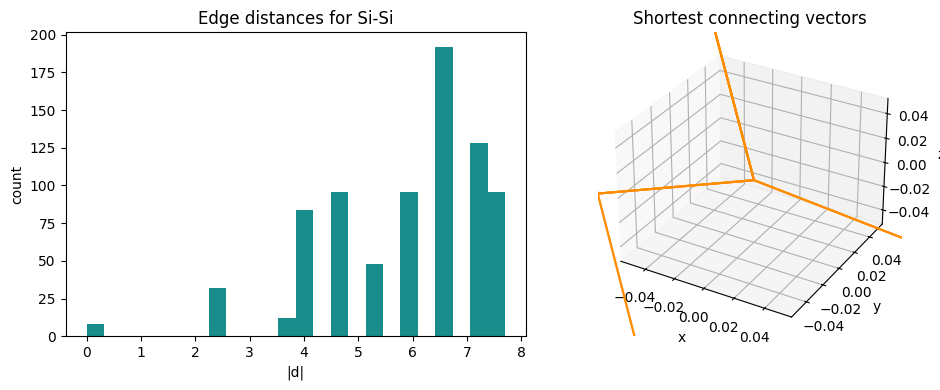

In [7]:
nonzero_edge_mask = edge_distances > 1.0e-8
nonzero_edge_indices = torch.nonzero(nonzero_edge_mask, as_tuple=False).flatten()
shortest_edges = nonzero_edge_indices[
    torch.argsort(edge_distances[nonzero_edge_indices])
][:12]
src_dst_pairs = edges[3:5].t()

print("Shortest connecting vectors for", key)
print("idx  src dst  shift            displacement                 |d|")
for idx in shortest_edges.tolist():
    sx, sy, sz, src, dst = [int(v) for v in edges[:, idx].tolist()]
    disp = edge_displacements[idx]
    print(
        f"{idx:3d}  {src:3d} {dst:3d}  "
        f"{(sx, sy, sz)!s:>12s}  {wrap_text_vec(disp, digits=5):>30s}  "
        f"{float(edge_distances[idx].item()):.5f}"
    )

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.hist(edge_distances.cpu().numpy(), bins=24, color="teal", alpha=0.9)
ax1.set_title(f"Edge distances for {key}")
ax1.set_xlabel("|d|")
ax1.set_ylabel("count")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for idx in shortest_edges.tolist():
    disp = edge_displacements[idx]
    ax2.quiver(
        0.0,
        0.0,
        0.0,
        float(disp[0]),
        float(disp[1]),
        float(disp[2]),
        color="darkorange",
        alpha=0.85,
        arrow_length_ratio=0.08,
    )
ax2.set_title("Shortest connecting vectors")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
show_figure(fig)

In [8]:
mapper = BlockIrrepMapper(snapshot.density.orbital_cfg, dtype=cfg.dtype)
density_vectors = density.to_vectors(mapper)
density_roundtrip = density_vectors.to_blocks(mapper)

roundtrip_error = torch.max(torch.abs(density_roundtrip[key] - density[key]))

print("Irrep round-trip")
print("vector key count:", len(density_vectors.pair_vectors))
print("vector shape for", key + ":", tuple(density_vectors[key].shape))
print("max abs round-trip error:", float(roundtrip_error.item()))

Irrep round-trip
vector key count: 1
vector shape for Si-Si: (792, 169)
max abs round-trip error: 1.1920928955078125e-07


In [9]:
density_path = output_dir / "si_density_blockmatrix.pt"
density.save(density_path)
density_loaded = BlockMatrix.load(density_path)

print("Portable density payload")
print("saved to:", density_path)
print("loaded basis:", density_loaded.basis)
print("loaded block count:", int(density_loaded[key].shape[0]))
print(
    "loaded round-trip check:",
    float(torch.max(torch.abs(density_loaded[key] - density[key])).item()),
)

kmesh = (5, 5, 5)
fractional_kpoints = fractional_kmesh_points(
    kmesh,
    device=snapshot.box.device,
    dtype=snapshot.box.dtype,
)
reciprocal = 2.0 * torch.pi * torch.linalg.inv(snapshot.box).T
kpoints_abs = fractional_kpoints @ reciprocal
kspace_snapshot = KSpaceSnapshot.from_shift_space(
    snapshot,
    kpoints_abs=kpoints_abs,
    kmesh=kmesh,
    shifts=shifts,
)

print("k-space transformation")
print("kmesh:", kmesh)
print("fractional k-points:", tuple(fractional_kpoints.shape))
print("absolute k-points:", tuple(kpoints_abs.shape))
print("k-space density tensor:", tuple(kspace_snapshot.density.matrices_k.shape))
print(
    "k-space density max |Im|:",
    float(kspace_snapshot.density.matrices_k.imag.abs().max().item()),
)

original_shift_density = block_matrix_to_shiftspace_dense(density, shifts=shifts)
recovered_shifts, recovered_shift_density = kspace_snapshot.density.to_shiftspace_dense(
    shifts=shifts
)
shift_identity = torch.equal(recovered_shifts.cpu(), shifts.cpu())
reconstruction_error = torch.max(
    torch.abs(recovered_shift_density - original_shift_density)
)
print("shift list preserved:", shift_identity)
print("shift-space dense shape:", tuple(original_shift_density.shape))
print("shift-space reconstruction max abs error:", float(reconstruction_error.item()))

Portable density payload
saved to: /home/bartek/casus/mandala/eval_outputs/demo_06_silicon_snapshot_density_blockmatrix/si_density_blockmatrix.pt
loaded basis: e3nn
loaded block count: 792
loaded round-trip check: 0.0
k-space transformation
kmesh: (5, 5, 5)
fractional k-points: (125, 3)
absolute k-points: (125, 3)
k-space density tensor: (125, 104, 104)
k-space density max |Im|: 0.2166012078523636
shift list preserved: True
shift-space dense shape: (45, 104, 104)
shift-space reconstruction max abs error: 2.3841863594498136e-07


/tmp/ipykernel_50064/281345723.py:45: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


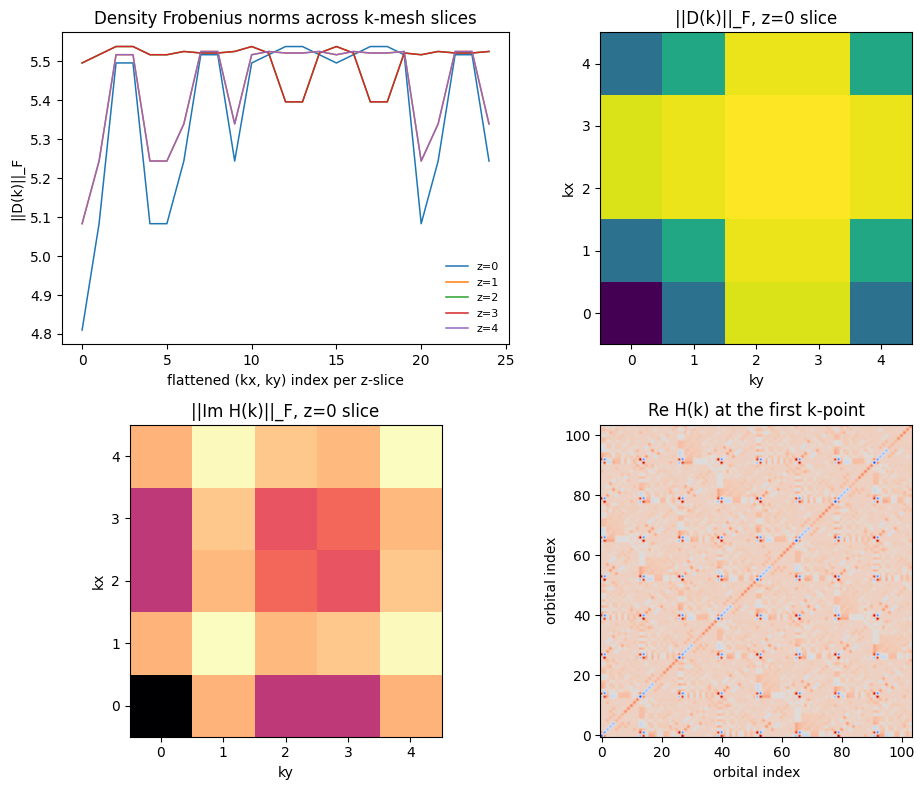

In [10]:
k_norms = torch.linalg.norm(
    kspace_snapshot.density.matrices_k.reshape(kspace_snapshot.density.matrices_k.shape[0], -1),
    dim=1,
)
k_norm_grid = k_norms.reshape(kmesh)
imag_norms = torch.linalg.norm(
    kspace_snapshot.hamiltonian.matrices_k.imag.reshape(
        kspace_snapshot.hamiltonian.matrices_k.shape[0], -1
    ),
    dim=1,
).reshape(kmesh)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for iz in range(kmesh[2]):
    axes[0, 0].plot(
        k_norm_grid[:, :, iz].reshape(-1).cpu().numpy(),
        label=f"z={iz}",
        linewidth=1.1,
    )
axes[0, 0].set_title("Density Frobenius norms across k-mesh slices")
axes[0, 0].set_xlabel("flattened (kx, ky) index per z-slice")
axes[0, 0].set_ylabel("||D(k)||_F")
axes[0, 0].legend(frameon=False, fontsize=8)

axes[0, 1].imshow(
    k_norm_grid[:, :, 0].cpu().numpy(),
    origin="lower",
    cmap="viridis",
)
axes[0, 1].set_title("||D(k)||_F, z=0 slice")
axes[0, 1].set_xlabel("ky")
axes[0, 1].set_ylabel("kx")

axes[1, 0].imshow(
    imag_norms[:, :, 0].cpu().numpy(),
    origin="lower",
    cmap="magma",
)
axes[1, 0].set_title("||Im H(k)||_F, z=0 slice")
axes[1, 0].set_xlabel("ky")
axes[1, 0].set_ylabel("kx")

gamma_h = kspace_snapshot.hamiltonian.matrices_k[0]
axes[1, 1].imshow(gamma_h.real.cpu().numpy(), origin="lower", cmap="coolwarm")
axes[1, 1].set_title("Re H(k) at the first k-point")
axes[1, 1].set_xlabel("orbital index")
axes[1, 1].set_ylabel("orbital index")
show_figure(fig)

In [11]:
print("Downstream feature example")
print("feature name: Frobenius norm per density edge")
edge_norms = torch.linalg.norm(blocks.reshape(blocks.shape[0], -1), dim=1)
print("count:", int(edge_norms.numel()))
print("min:", float(edge_norms.min().item()))
print("mean:", float(edge_norms.mean().item()))
print("max:", float(edge_norms.max().item()))

Downstream feature example
feature name: Frobenius norm per density edge
count: 792
min: 0.017436297610402107
mean: 0.09531410038471222
max: 1.3635128736495972
